In [1]:
# Parameters (papermill injects these)
MARKET = "aaa_gas_us"
# FAST = True → 3 CV folds per model, for quick checks of the pipeline
FAST = False

In [2]:
# Parameters
MARKET = "aaa_gas_us"
FAST = False

In [3]:
import warnings

warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss

from prediction_markets_forecasting import kalshi
from prediction_markets_forecasting.markets import build
from prediction_markets_forecasting.pricing import (
    bracket_label,
    edge_table,
    implied_distribution,
    model_distribution,
)
from prediction_markets_forecasting.selection import discover, select
from prediction_markets_forecasting.specs import get_spec
from prediction_markets_forecasting.stationarity import decide
from prediction_markets_forecasting.tournament import (
    ETS_CONFIGS,
    NIXTLA,
    SARIMAX_CONFIGS,
    run_tournament,
    timed,
)

plt.rcParams.update(
    {
        "figure.figsize": (14, 5),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "lines.linewidth": 2,
        "figure.dpi": 100,
    }
)
pd.set_option("display.width", 200)

spec = get_spec(MARKET)
if FAST:
    for c in spec.freqs.values():
        c.n_folds = 3
AS_OF = pd.Timestamp.now().normalize()
FREQS = list(spec.freqs)
ERR_SCALE, ERR_UNIT = (100, "¢") if spec.units.startswith("$") else (1, spec.units)
OUT = Path("../data/outputs")
OUT.mkdir(parents=True, exist_ok=True)
SNAP = Path("../data/kalshi_snapshots")
SNAP.mkdir(parents=True, exist_ok=True)

display(
    Markdown(
        f"""
# Notebook {spec.number} — {spec.title}

**Family:** {spec.family} &nbsp;|&nbsp; **As of:** {AS_OF:%Y-%m-%d} &nbsp;|&nbsp; **Market key:** `{spec.key}`

**Underlying (X):** {spec.underlying}

| Frequency | Kalshi series | Grid | Season | CV folds (one-step) |
|---|---|---|---|---|
"""
        + "\n".join(
            f"| {k} | `{c.series}` | {c.freq} | {c.season} | {c.n_folds} |"
            for k, c in spec.freqs.items()
        )
    )
)


# Notebook 01 — AAA US Regular Gas Price

**Family:** B lagging statistic &nbsp;|&nbsp; **As of:** 2026-09-23 &nbsp;|&nbsp; **Market key:** `aaa_gas_us`

**Underlying (X):** AAA national average price of regular gasoline ($/gal) on the contract date

| Frequency | Kalshi series | Grid | Season | CV folds (one-step) |
|---|---|---|---|---|
| daily | `KXAAAGASD` | D | 7 | 28 |
| weekly | `KXAAAGASW` | W-MON | 52 | 26 |
| monthly | `KXAAAGASM` | ME | 12 | 24 |

---
### Project Overview

Every market in this repo is rendered from **the same notebook**, which follows the pipeline of
*Individual Project — Time Series Analysis & Forecasting (Logitech, MAS 640)*:

| Stage | Description |
|-------|-------------|
| **Part 1** | Data loading & cleaning — the target straight from Kalshi's resolution values, long-history proxy, drivers |
| **Part 2** | EDA — trends, seasonality, size of one-step moves, **driver discovery** |
| **Part 3** | Diagnostics — ADF/KPSS, decomposition, ACF/PACF, **automatic differencing & cointegration** |
| **Part 4** | Tournament — SARIMAX, Log-SARIMAX, SARIMAX-X, ETS, 7 Nixtla, GB/RF (± drivers), baselines, ensemble |
| **Part 5** | Critique & next steps |
| **Part 6** | **Kalshi translation** — forecast distribution → P(each bracket) → edge vs market price after fees |

### How the Kalshi market connects to X
Every contract is a yes/no question on one number on one date: *X > K*, *X < K* or *K₁ ≤ X ≤ K₂*.
The price of "Yes" is the crowd's probability. We forecast X, turn the model's cross-validation errors into a
distribution X ~ N(forecast + bias, σ_CV), compute P(bracket) for every market on the ladder, and compare it
with the price after Kalshi's fee.

### How drivers are chosen (Part 2.6)
1. Economic prior (supply chain, physics) + a **placebo** that must be rejected.
2. Lead-lag correlation of **changes** (never levels): observed drivers must lead by ≥ 1 period; forecasts
   ("ahead" drivers, known before the day) may count at lag 0.
3. Granger causality (p < 0.01), strongest first, skipping near-duplicates (|corr of changes| ≥ 0.9), max 3.
4. Final judge: the same model with vs without drivers in out-of-sample CV (Part 4).

### Stationarity is automatic (Part 3.4)
`d` from ADF + KPSS (both must agree the series is stationary, otherwise difference), `D` from STL seasonal
strength, drivers enter as an error-correction term if cointegrated (Engle-Granger), as changes if not,
as levels only if the target is stationary. AIC only compares SARIMAX orders with the same `d`/`D`;
ML models predict the change when `d ≥ 1`.

---
# Part 1: Data Loading & Cleaning

The market builder (`markets.py`) pulls the exact values each Kalshi event settled on (`expiration_value`),
validates them against a long-history public proxy, and prepares every driver as *the value known at each date*
(no look-ahead).

In [4]:
data = build(spec, AS_OF)
Y, X_by = data.Y, data.X
for title, table in data.reports.items():
    print("=" * 90)
    print(title.upper())
    print("=" * 90)
    display(table.round(4))
for n in data.notes:
    print("•", n)

KALSHI SETTLEMENT DATA QUALITY


,frequency,series,markets,events,foreign_events_dropped,non_numeric_events,clean_obs,start,end
0,daily,KXAAAGASD,3440,207,0,0,207,2023-09-18,2026-09-23
1,weekly,KXAAAGASW,976,137,2,1,134,2023-10-09,2026-09-21
2,monthly,KXAAAGASM,425,33,0,0,33,2023-12-31,2026-08-31


BRIDGE: RESOLUTION SOURCE VS LONG-HISTORY PROXY


,frequency,overlap,mean_diff,std_diff,corr_levels,corr_changes
0,weekly,134,0.0151,0.0104,0.9997,0.9970
1,monthly,33,0.0204,0.0128,0.9995,0.9972


• Weekly: AAA − EIA bias = +1.51¢ applied to EIA before AAA history (134 AAA weeks, 6 forward-filled gaps).
• Monthly: AAA − EIA(interp) bias = +2.04¢ (33 AAA month-ends).
• Daily: last contiguous AAA block from 2026-03-26 (0 forward-filled days).


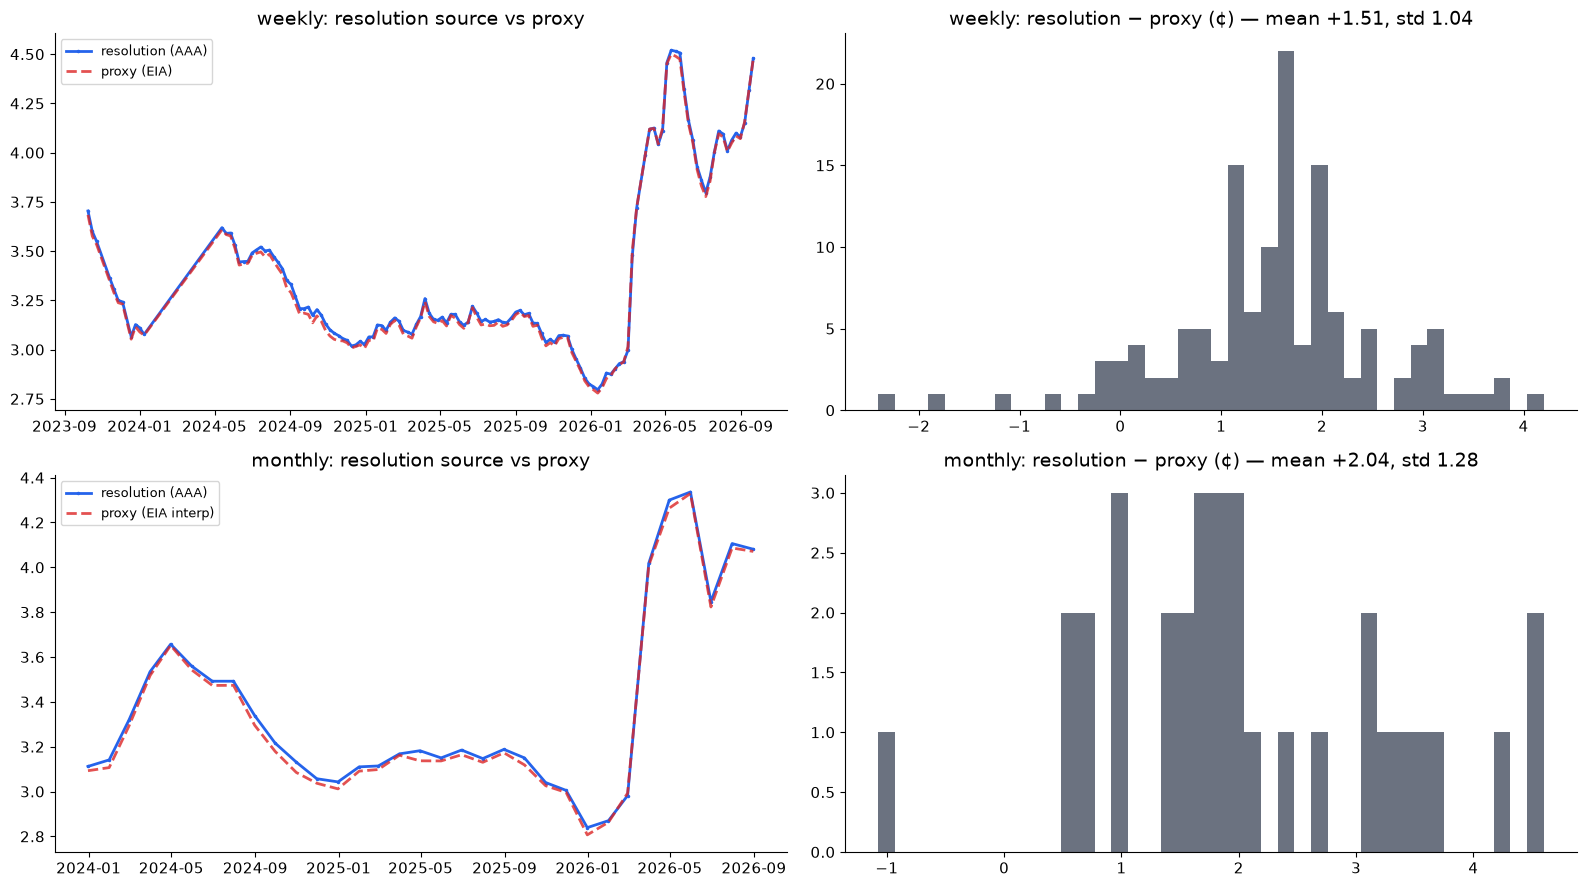

In [5]:
# Resolution source vs long-history proxy
if data.bridges:
    fig, axes = plt.subplots(
        len(data.bridges), 2, figsize=(16, 4.5 * len(data.bridges)), squeeze=False
    )
    for i, (k, b) in enumerate(data.bridges.items()):
        axes[i, 0].plot(
            b.index, b.iloc[:, 0], ".-", color="#2563eb", label=b.columns[0], markersize=3
        )
        axes[i, 0].plot(b.index, b.iloc[:, 1], "--", color="#dc2626", label=b.columns[1], alpha=0.8)
        axes[i, 0].set_title(f"{k}: resolution source vs proxy")
        axes[i, 0].legend(fontsize=9)
        d = (b.iloc[:, 0] - b.iloc[:, 1]) * ERR_SCALE
        axes[i, 1].hist(d, bins=40, color="#6b7280")
        axes[i, 1].set_title(
            f"{k}: resolution − proxy ({ERR_UNIT}) — mean {d.mean():+.2f}, std {d.std():.2f}"
        )
    plt.tight_layout()
    plt.show()

In [6]:
print("=" * 90)
print("FINAL CLEANED DATA SUMMARY")
print("=" * 90)
display(
    pd.DataFrame(
        [
            {
                "frequency": k,
                "kalshi_series": spec.freqs[k].series,
                "n_obs": len(y),
                "start": y.index.min().date(),
                "end": y.index.max().date(),
                "last_value": y.iloc[-1],
                "mean": y.mean(),
                f"std_1step_change_{ERR_UNIT}": y.diff().std() * ERR_SCALE,
                "from_resolution_source_%": (data.source[k].str.contains("Kalshi|AAA")).mean()
                * 100,
            }
            for k, y in Y.items()
        ]
    ).round(3)
)
print("Driver candidates:")
display(data.driver_info)

FINAL CLEANED DATA SUMMARY


,frequency,kalshi_series,n_obs,start,end,last_value,mean,std_1step_change_¢,from_resolution_source_%
0,daily,KXAAAGASD,182,2026-03-26,2026-09-23,4.474,4.152,2.215,100.000
1,weekly,KXAAAGASW,612,2015-01-05,2026-09-21,4.479,2.925,6.452,21.895
2,monthly,KXAAAGASM,236,2007-01-31,2026-08-31,4.081,3.022,20.386,13.983


Driver candidates:


,description,ahead,start,end,n_obs,days_stale
driver,,,,,,
DGASUSGULF,Gulf Coast gasoline spot (FRED),False,1986-06-02,2026-09-22,9202,1
DGASNYH,NY Harbor gasoline spot (FRED),False,1986-06-02,2026-09-22,9141,1
DCOILWTICO,WTI crude spot (FRED),False,1986-01-02,2026-09-22,9507,1
DCOILBRENTEU,Brent crude spot (FRED),False,1987-05-20,2026-09-22,9092,1
DHOILNYH,NY Harbor heating oil spot (FRED),False,1986-06-02,2026-09-22,8790,1
DTWEXBGS,Trade-weighted US dollar (FRED),False,2006-01-02,2026-09-18,5193,5
DGS10,10Y Treasury yield — placebo (FRED),False,1962-01-02,2026-09-22,16166,1
RB=F,RBOB gasoline futures (Yahoo),False,2004-01-05,2026-09-23,5716,0
CL=F,WTI crude futures (Yahoo),False,2004-01-05,2026-09-23,5713,0


---
# Part 2: Exploratory Data Analysis (EDA)
## 2.1 Target series

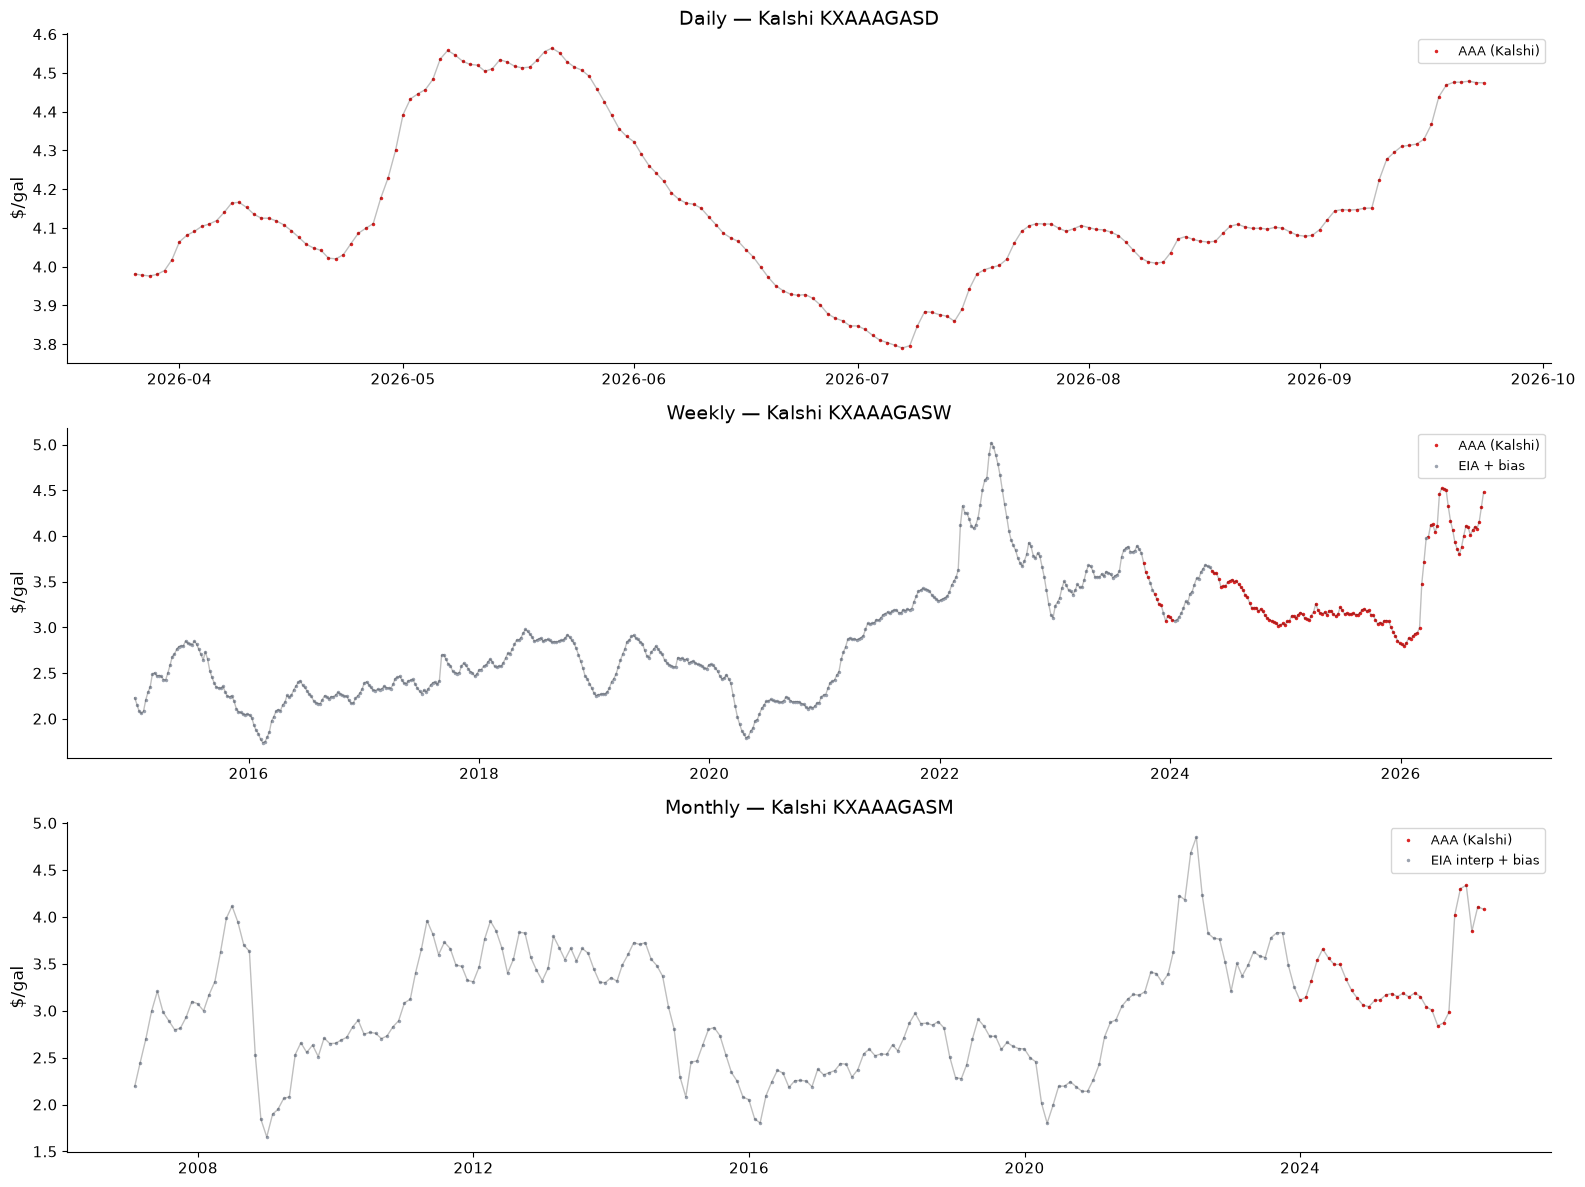

In [7]:
fig, axes = plt.subplots(len(Y), 1, figsize=(16, 4 * len(Y)), squeeze=False)
palette = ["#dc2626", "#9ca3af", "#16a34a", "#2563eb"]
for ax, (k, y) in zip(axes[:, 0], Y.items(), strict=False):
    for (src, idx), color in zip(
        data.source[k].groupby(data.source[k]).groups.items(), palette, strict=False
    ):
        ax.plot(idx, y.loc[idx], ".", markersize=3, color=color, label=src)
    ax.plot(y.index, y.values, color="black", alpha=0.25, linewidth=1)
    ax.set_title(f"{k.capitalize()} — Kalshi {spec.freqs[k].series}")
    ax.set_ylabel(spec.units)
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 2.2 Target vs its strongest driver candidates (last 3 years)

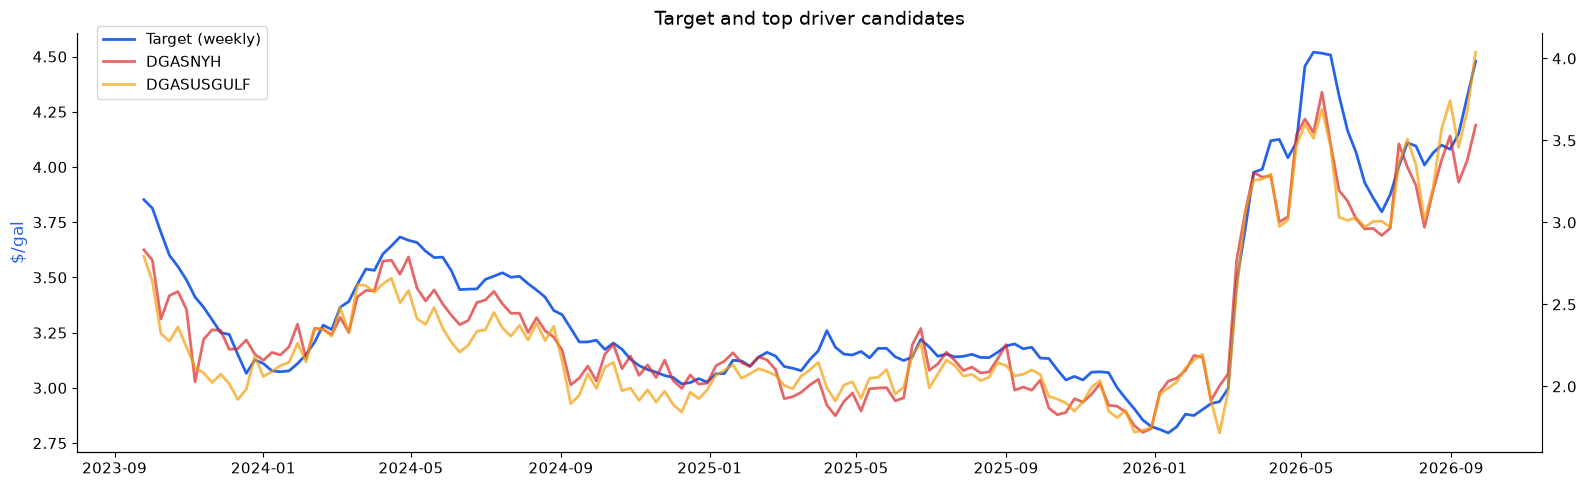

In [8]:
DISC = spec.discovery_freq
yD, XD = Y[DISC], X_by[DISC].reindex(Y[DISC].index)
top = (
    XD.drop(columns=[data.placebo], errors="ignore")
    .corrwith(yD)
    .abs()
    .sort_values(ascending=False)
    .index[:2]
)
recent = yD.index >= yD.index.max() - pd.DateOffset(years=3)
fig, ax1 = plt.subplots(figsize=(16, 5))
ax1.plot(yD.index[recent], yD[recent], color="#2563eb", label=f"Target ({DISC})")
ax1.set_ylabel(spec.units, color="#2563eb")
ax2 = ax1.twinx()
for c, color in zip(top, ["#dc2626", "#f59e0b"], strict=False):
    ax2.plot(XD.index[recent], XD[c][recent], color=color, alpha=0.7, label=c)
ax2.spines["right"].set_visible(True)
fig.legend(loc="upper left", bbox_to_anchor=(0.06, 0.95))
ax1.set_title("Target and top driver candidates")
plt.tight_layout()
plt.show()

## 2.3 Year-over-Year Growth Rates

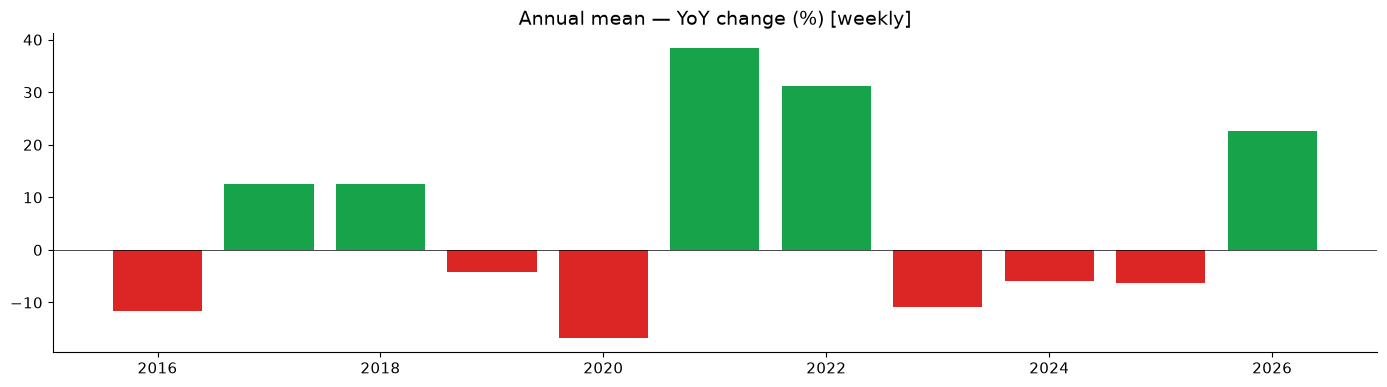

              2015    2016   2017    2018   2019    2020    2021    2022    2023   2024   2025    2026
annual_mean  2.444   2.158   2.43   2.734  2.619   2.183   3.023   3.966   3.534  3.324  3.112   3.814
yoy_%          NaN -11.700  12.60  12.500 -4.200 -16.700  38.500  31.200 -10.900 -5.900 -6.400  22.500


In [9]:
annual = yD.groupby(yD.index.year).mean()
yoy = annual.pct_change() * 100
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(
    yoy.dropna().index,
    yoy.dropna().values,
    color=["#16a34a" if v > 0 else "#dc2626" for v in yoy.dropna()],
)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title(f"Annual mean — YoY change (%) [{DISC}]")
plt.tight_layout()
plt.show()
print(pd.DataFrame({"annual_mean": annual.round(3), "yoy_%": yoy.round(1)}).T.to_string())

## 2.4 Seasonality Patterns

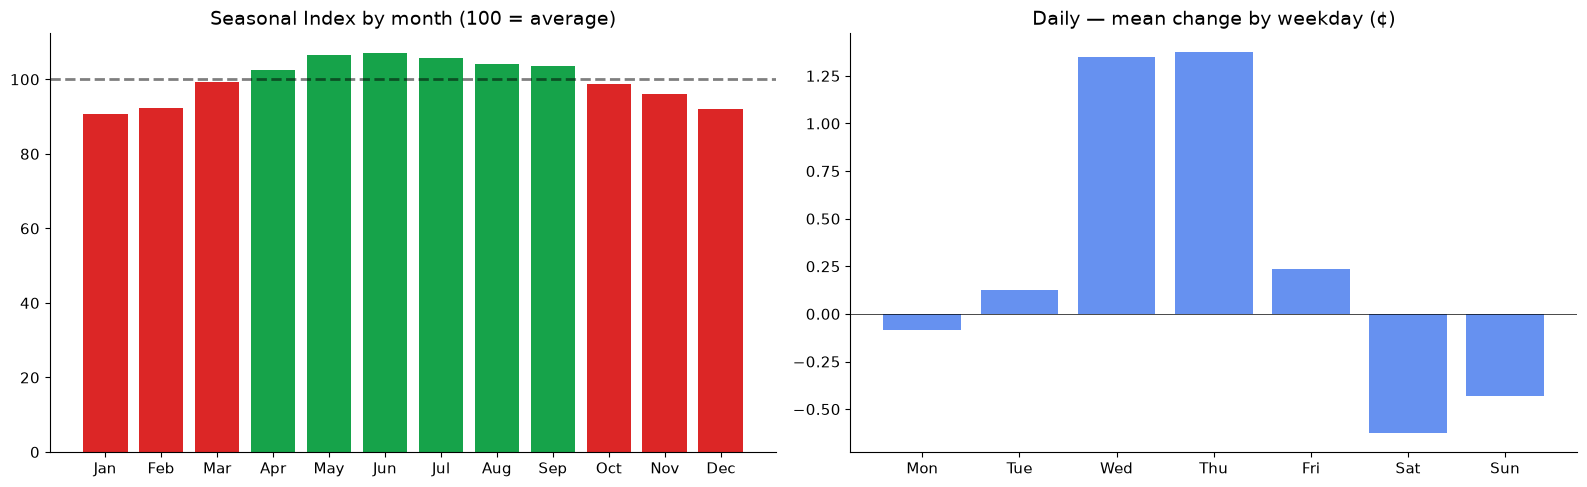

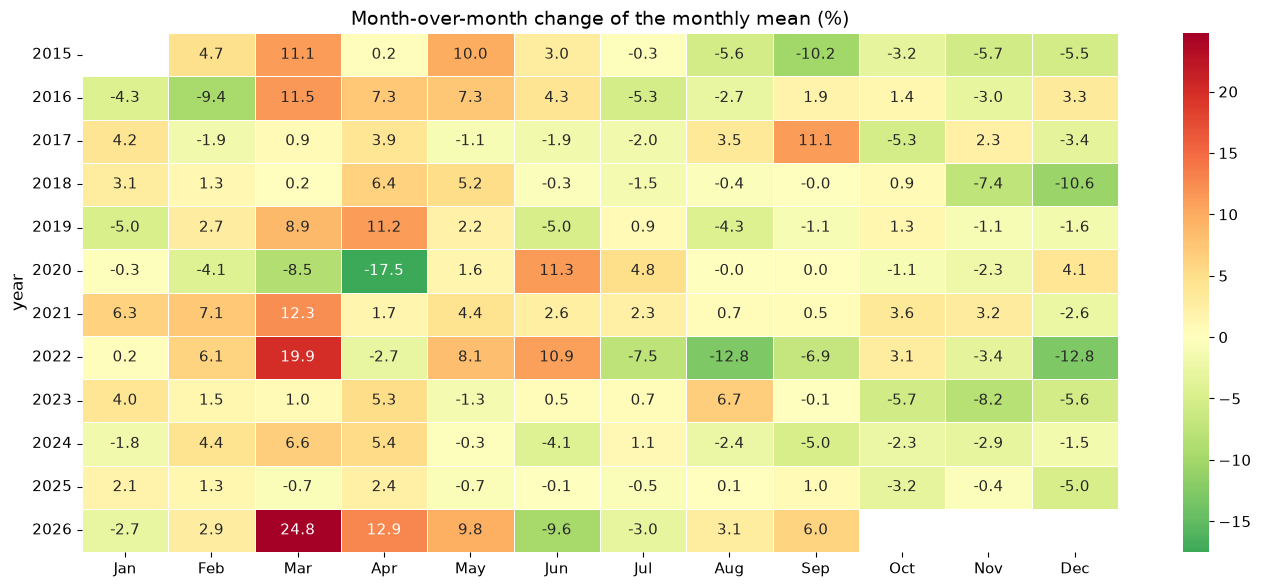

In [10]:
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly_mean = yD.resample("ME").mean()
seasonal_idx = monthly_mean.groupby(monthly_mean.index.month).mean() / monthly_mean.mean() * 100
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(
    seasonal_idx.index,
    seasonal_idx.values,
    color=["#dc2626" if v < 100 else "#16a34a" for v in seasonal_idx],
)
axes[0].axhline(100, color="black", linestyle="--", alpha=0.5)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names)
axes[0].set_title("Seasonal Index by month (100 = average)")
if "daily" in Y:
    dow = Y["daily"].diff().groupby(Y["daily"].index.dayofweek).mean() * ERR_SCALE
    axes[1].bar(
        ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], dow.values, color="#2563eb", alpha=0.7
    )
    axes[1].axhline(0, color="black", linewidth=0.5)
    axes[1].set_title(f"Daily — mean change by weekday ({ERR_UNIT})")
plt.tight_layout()
plt.show()

heat = monthly_mean.pct_change().mul(100).to_frame("chg")
heat = heat.assign(year=heat.index.year, month=heat.index.month).pivot_table(
    index="year", columns="month", values="chg"
)
heat.columns = [month_names[m - 1] for m in heat.columns]
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heat.tail(12), annot=True, fmt=".1f", cmap="RdYlGn_r", center=0, linewidths=0.5, ax=ax)
ax.set_title("Month-over-month change of the monthly mean (%)")
plt.tight_layout()
plt.show()

## 2.5 Size of one-step moves (sets how many Kalshi brackets are in play)

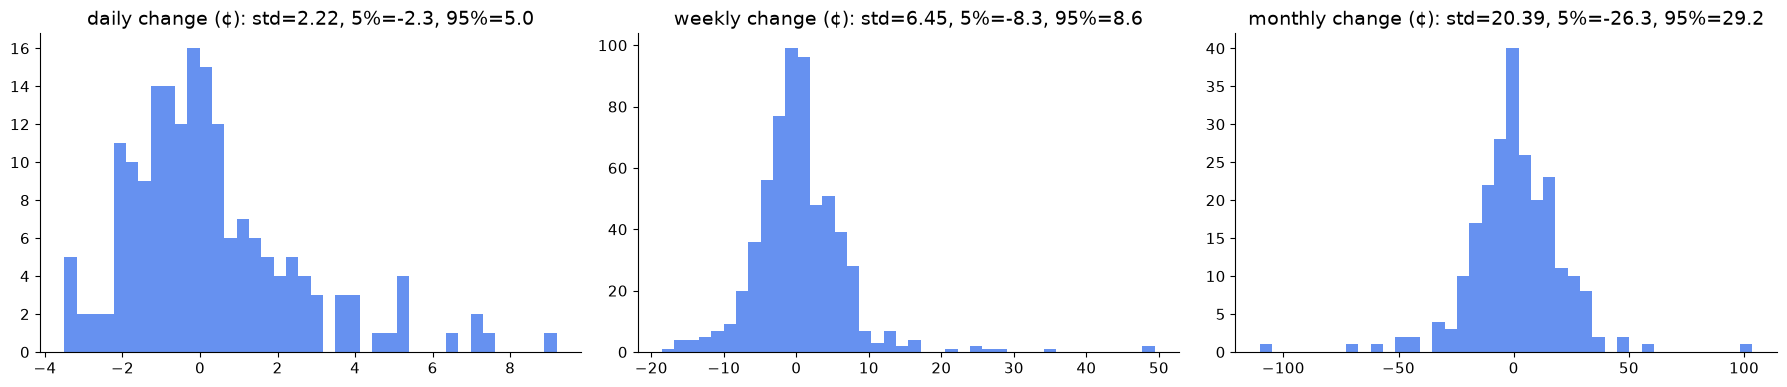

In [11]:
fig, axes = plt.subplots(1, len(Y), figsize=(6 * len(Y), 4), squeeze=False)
for ax, (k, y) in zip(axes[0], Y.items(), strict=False):
    chg = y.diff().dropna() * ERR_SCALE
    ax.hist(chg, bins=40, color="#2563eb", alpha=0.7)
    ax.set_title(
        f"{k} change ({ERR_UNIT}): std={chg.std():.2f}, 5%={chg.quantile(.05):.1f}, 95%={chg.quantile(.95):.1f}"
    )
plt.tight_layout()
plt.show()

## 2.6 Driver discovery — which variables move *before* X?

**(a) Correlation of levels** — shown only to demonstrate why it misleads (trends and seasons correlate with anything).

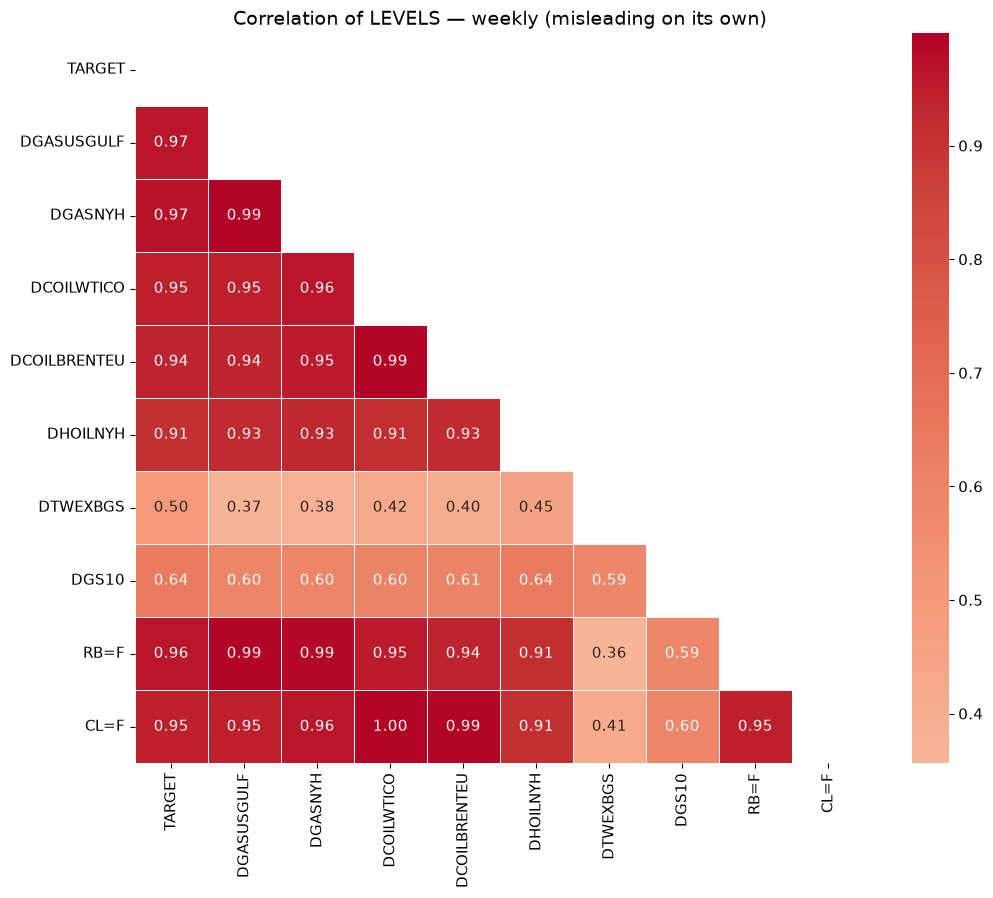

In [12]:
lvl = pd.concat([yD.rename("TARGET"), XD], axis=1).dropna()
fig, ax = plt.subplots(figsize=(11, 9))
corr = lvl.corr()
sns.heatmap(
    corr,
    mask=np.triu(np.ones_like(corr, dtype=bool)),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title(f"Correlation of LEVELS — {DISC} (misleading on its own)")
plt.tight_layout()
plt.show()

**(b) Lead-lag correlation of changes** corr(ΔX_t, Δdriver_{t−k}) and **(c) Granger causality**.
Observed drivers must lead by k ≥ 1; forecasts known before the day ("ahead") may count at k = 0.

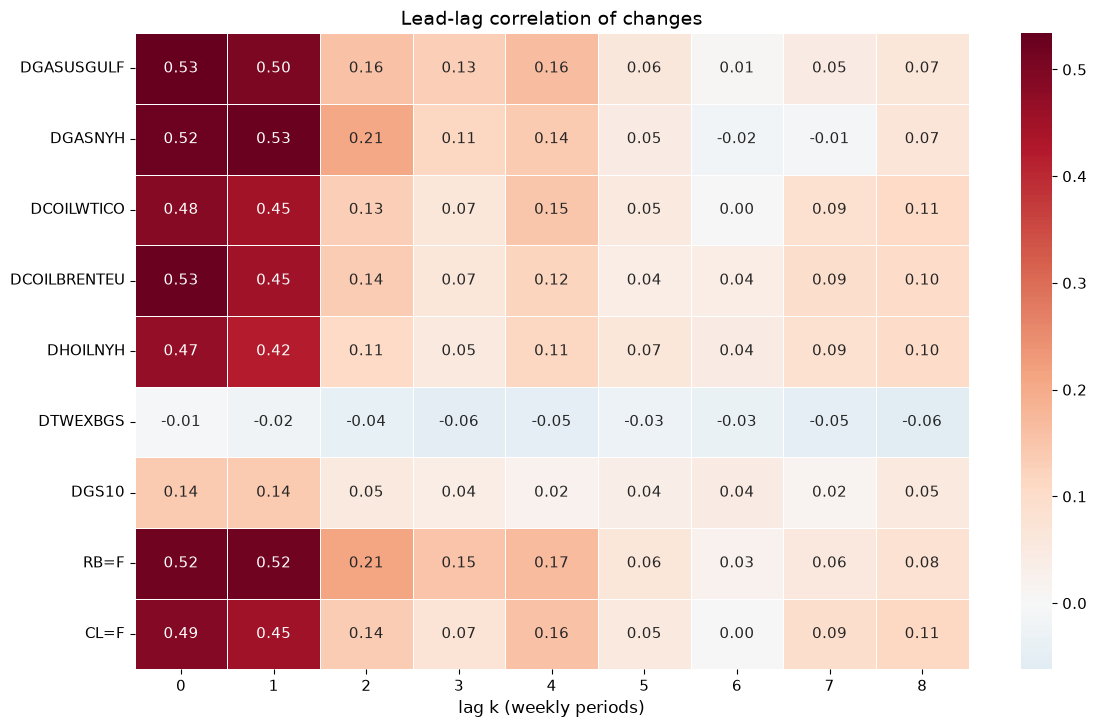

,ahead,level_corr,corr_k0,best_pred_lag,corr_best_pred,granger_p,abs_pred_corr
driver,,,,,,,
DGASNYH,False,0.9705,0.5214,1,0.5258,0.0000,0.5258
RB=F,False,0.9647,0.5196,1,0.5162,0.0000,0.5162
DGASUSGULF,False,0.9654,0.5341,1,0.5021,0.0000,0.5021
DCOILBRENTEU,False,0.9385,0.5267,1,0.4543,0.0000,0.4543
CL=F,False,0.9451,0.4906,1,0.4524,0.0000,0.4524
DCOILWTICO,False,0.9484,0.4844,1,0.4456,0.0000,0.4456
DHOILNYH,False,0.9107,0.4693,1,0.4181,0.0000,0.4181
DGS10,False,0.6396,0.1387,1,0.1408,0.0521,0.1408
DTWEXBGS,False,0.4974,-0.0081,8,-0.0621,0.5714,0.0621


In [13]:
MAX_LAG = 14 if DISC == "daily" else 8
drivers_table, cc = discover(yD, XD, data.ahead, MAX_LAG)
fig, ax = plt.subplots(figsize=(min(18, 4 + MAX_LAG), 0.6 * len(cc) + 2))
sns.heatmap(cc, annot=True, fmt=".2f", cmap="RdBu_r", center=0, linewidths=0.5, ax=ax)
ax.set_xlabel(f"lag k ({DISC} periods)")
ax.set_title("Lead-lag correlation of changes")
plt.tight_layout()
plt.show()
display(drivers_table.round(4))

In [14]:
SELECTED = select(drivers_table, XD)
print("Selected exogenous drivers:")
for c in SELECTED:
    r = drivers_table.loc[c]
    print(
        f'  {c:22s} {"(ahead) " if r["ahead"] else "        "}corr@lag{r["best_pred_lag"]}={r["corr_best_pred"]:+.2f}  '
        f'Granger p={r["granger_p"]:.1e}'
    )
if data.placebo:
    ok = data.placebo not in SELECTED
    print(
        f'\nPlacebo {data.placebo}: Granger p = {drivers_table.loc[data.placebo, "granger_p"]:.3f} → '
        + ("correctly rejected" if ok else "WARNING: selected — the filters are too loose")
    )

Selected exogenous drivers:
  DGASNYH                        corr@lag1=+0.53  Granger p=5.5e-18
  RB=F                           corr@lag1=+0.52  Granger p=4.5e-18
  DGASUSGULF                     corr@lag1=+0.50  Granger p=1.1e-16

Placebo DGS10: Granger p = 0.052 → correctly rejected


## 2.7 Key EDA Findings

| Question | Where to look |
|---|---|
| Is the long-history proxy faithful to the resolution source? | Part 1 bridge table and plots |
| Which drivers lead X? | 2.6 — lead-lag heatmap and Granger table |
| Is the selection honest? | 2.6 — the placebo must be rejected |
| How wide is the distribution that matters for brackets? | 2.5 — std of one-step changes |

---
# Part 3: Time Series Diagnostics
## 3.1 Stationarity Tests (ADF & KPSS)

In [15]:
rows = []
for k, ts in Y.items():
    adf_p = adfuller(ts.dropna(), autolag="AIC")[1]
    kpss_p = kpss(ts.dropna(), regression="ct")[1]
    adf_d = adfuller(ts.diff().dropna(), autolag="AIC")[1]
    rows.append(
        {
            "series": k,
            "ADF_p": adf_p,
            "ADF": "Stationary" if adf_p < 0.05 else "Non-stationary",
            "KPSS(ct)_p": kpss_p,
            "KPSS": "Non-stationary" if kpss_p < 0.05 else "Stationary",
            "ADF_diff1_p": adf_d,
            "ADF_diff1": "Stationary" if adf_d < 0.05 else "Non-stationary",
        }
    )
display(pd.DataFrame(rows).round(4))

,series,ADF_p,ADF,KPSS(ct)_p,KPSS,ADF_diff1_p,ADF_diff1
0,daily,0.4088,Non-stationary,0.0153,Non-stationary,0.0054,Stationary
1,weekly,0.4261,Non-stationary,0.0454,Non-stationary,0.0000,Stationary
2,monthly,0.0046,Stationary,0.0129,Non-stationary,0.0000,Stationary


## 3.2 Seasonal Decomposition

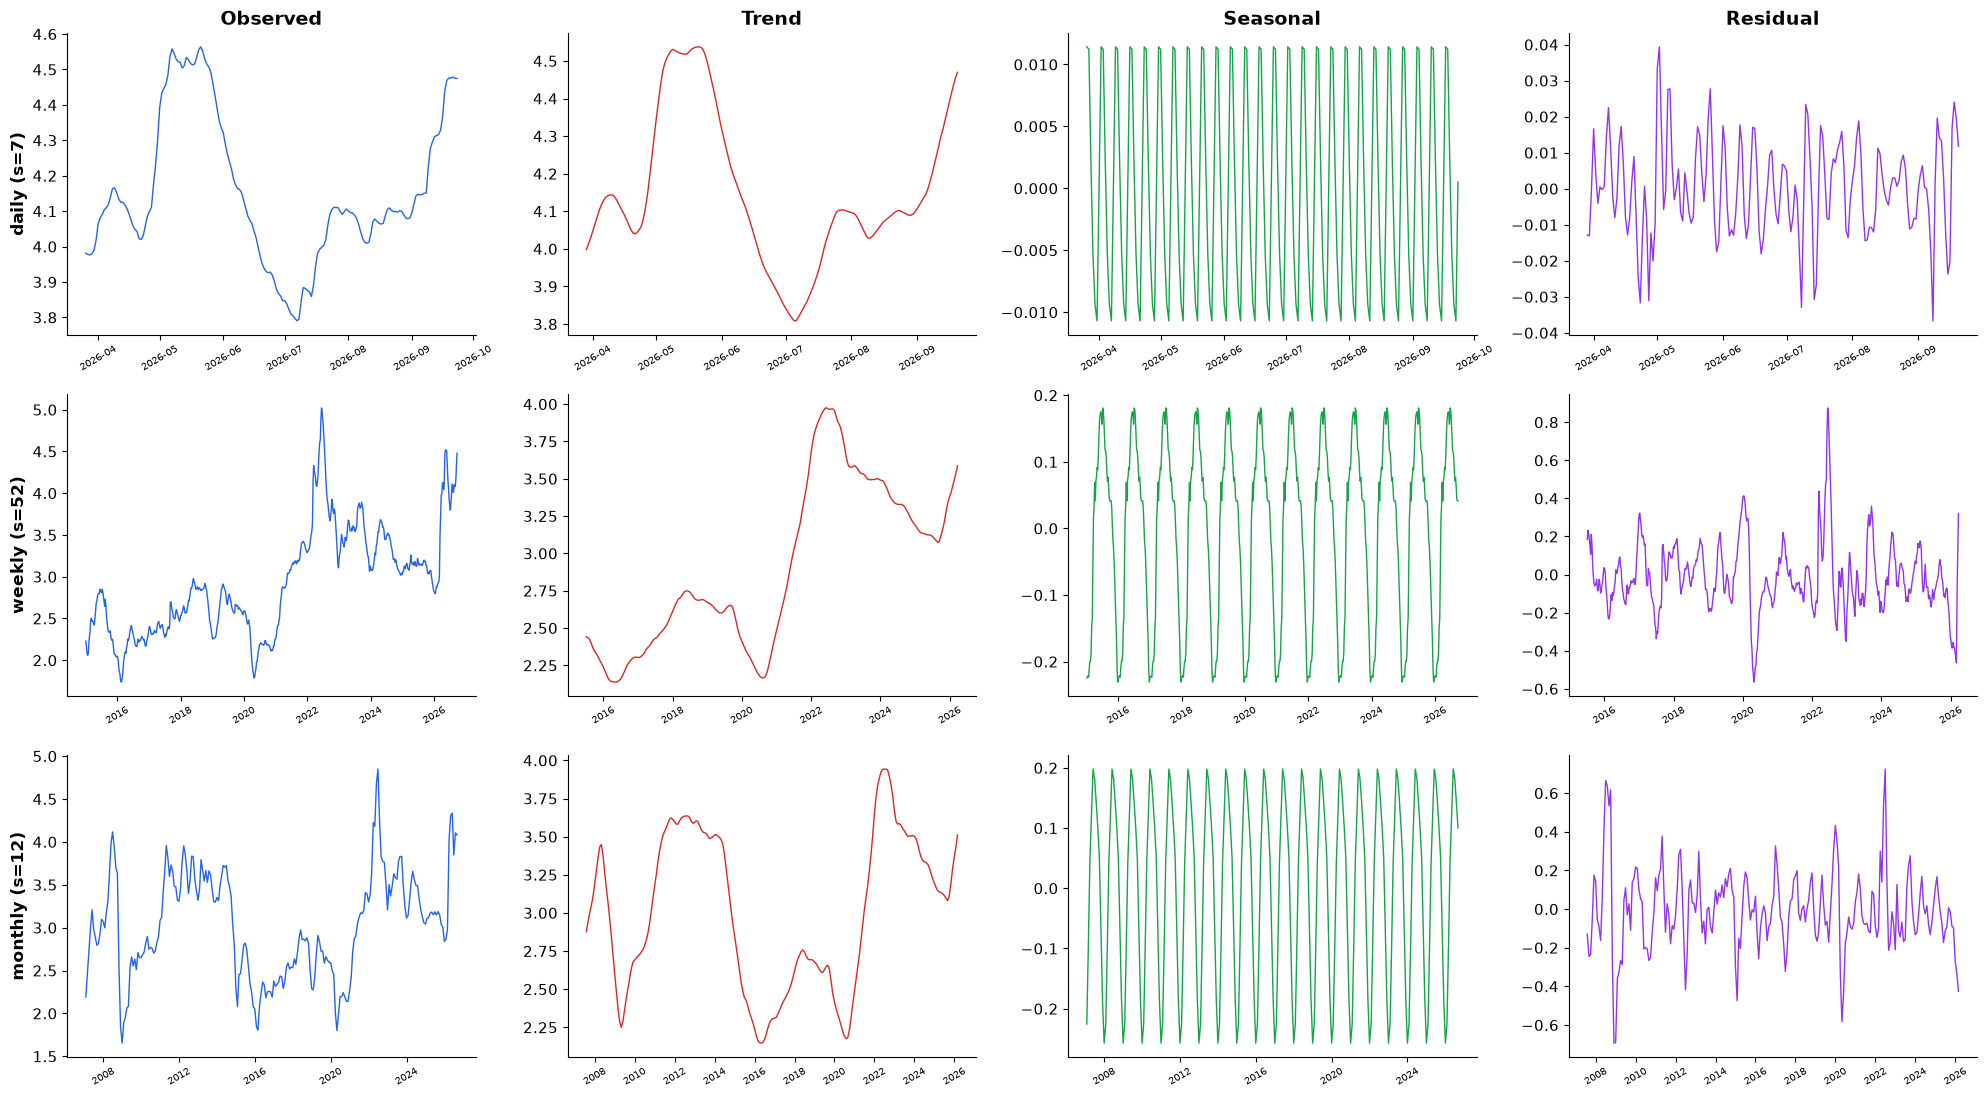

In [16]:
fig, axes = plt.subplots(len(Y), 4, figsize=(20, 3.7 * len(Y)), squeeze=False)
colors = ["#2563eb", "#dc2626", "#16a34a", "#9333ea"]
for i, (k, ts) in enumerate(Y.items()):
    dec = seasonal_decompose(ts, model="additive", period=spec.freqs[k].season)
    for j, ((title, s), color) in enumerate(
        zip(
            [
                ("Observed", dec.observed),
                ("Trend", dec.trend),
                ("Seasonal", dec.seasonal),
                ("Residual", dec.resid),
            ],
            colors,
            strict=False,
        )
    ):
        axes[i, j].plot(s.index, s.values, color=color, linewidth=1)
        if i == 0:
            axes[i, j].set_title(title, fontweight="bold")
        axes[i, j].tick_params(axis="x", rotation=30, labelsize=7)
    axes[i, 0].set_ylabel(f"{k} (s={spec.freqs[k].season})", fontweight="bold")
plt.tight_layout()
plt.show()

## 3.3 ACF & PACF Analysis

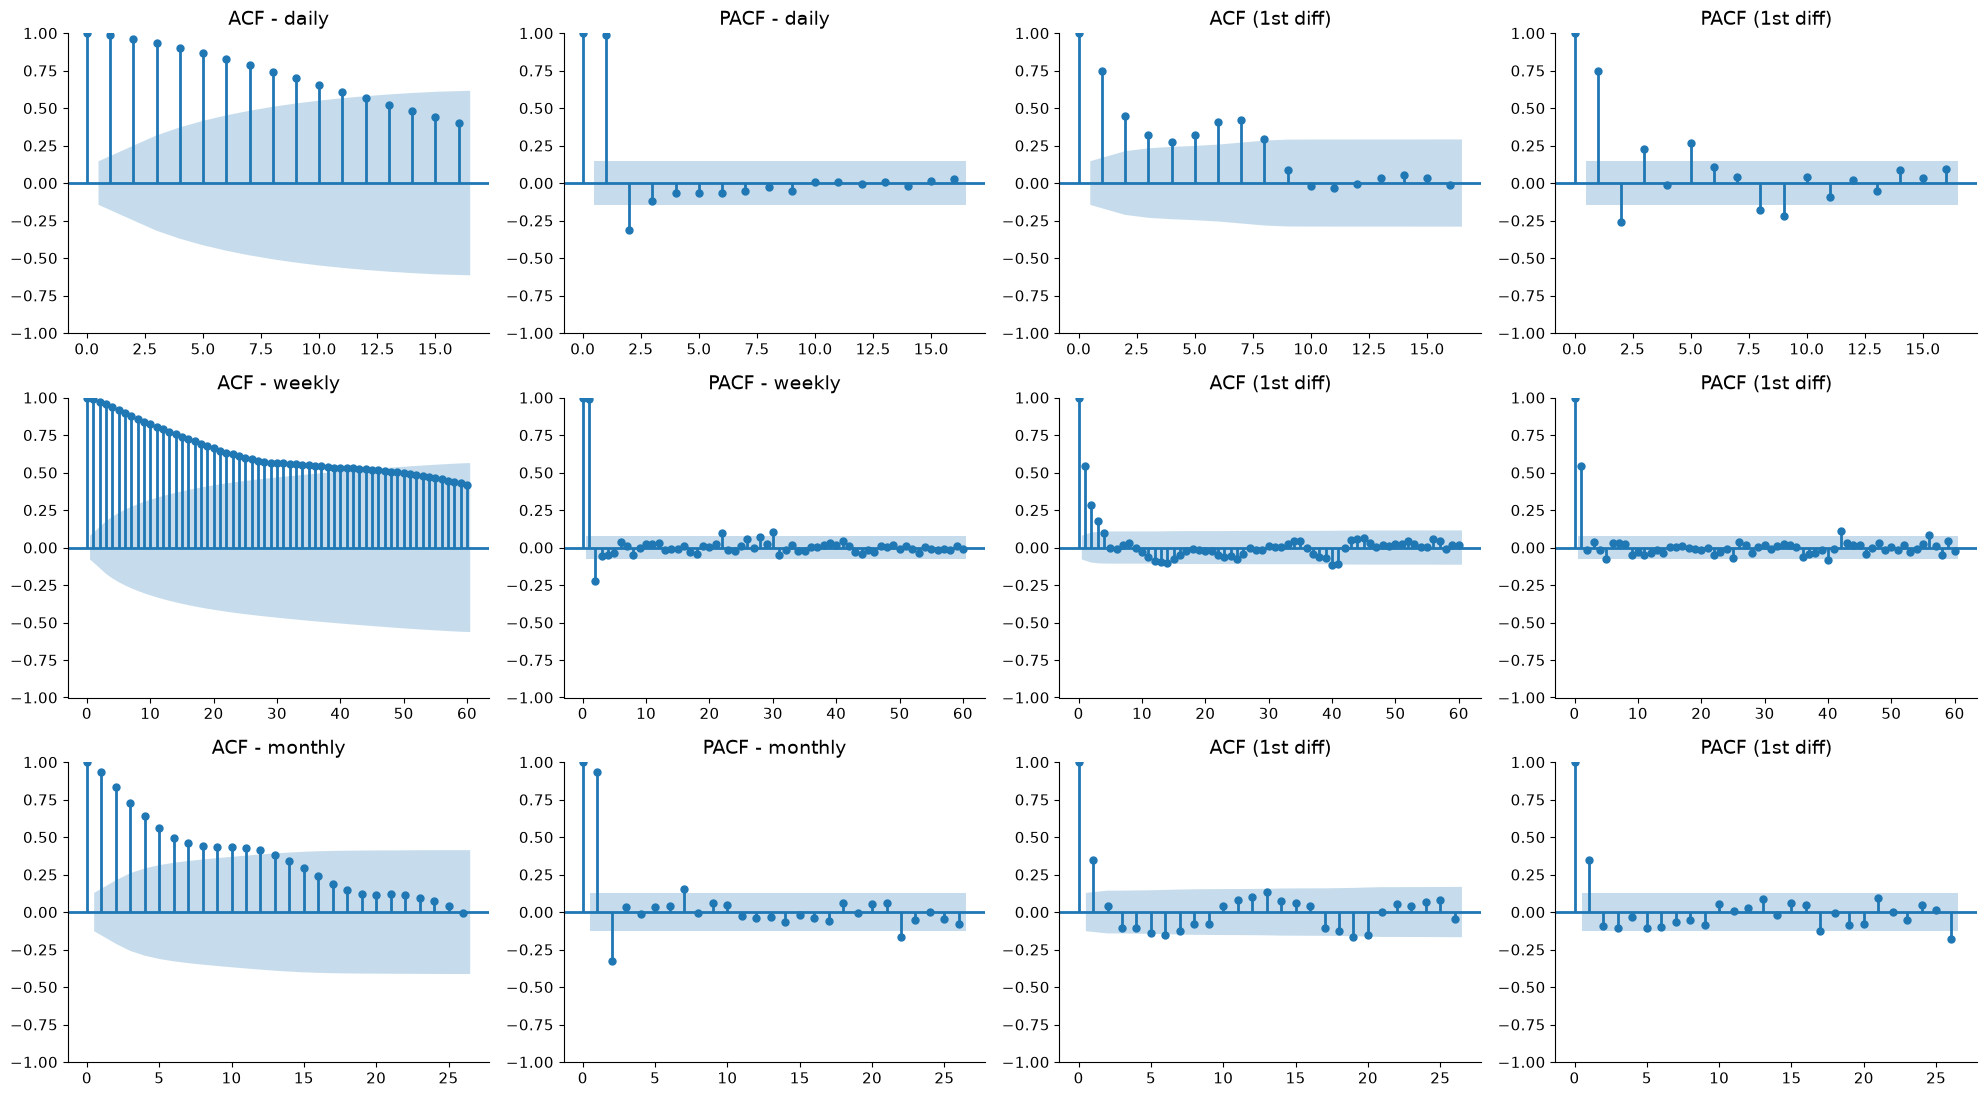

In [17]:
fig, axes = plt.subplots(len(Y), 4, figsize=(20, 3.7 * len(Y)), squeeze=False)
for i, (k, ts) in enumerate(Y.items()):
    lags = min(2 * spec.freqs[k].season + 2, len(ts) // 2 - 1, 60)
    plot_acf(ts, ax=axes[i, 0], lags=lags, title=f"ACF - {k}")
    plot_pacf(ts, ax=axes[i, 1], lags=lags, title=f"PACF - {k}")
    plot_acf(ts.diff().dropna(), ax=axes[i, 2], lags=lags, title="ACF (1st diff)")
    plot_pacf(ts.diff().dropna(), ax=axes[i, 3], lags=lags, title="PACF (1st diff)")
plt.tight_layout()
plt.show()

## 3.4 Automatic Differencing & Cointegration Decisions

Computed, not chosen by hand — every model in Part 4 follows this table.

| Decision | Rule |
|---|---|
| `d` | Difference until ADF rejects a unit root **and** KPSS does not reject stationarity; if they disagree, difference |
| `D` | One seasonal difference if STL seasonal strength F_s > 0.64 |
| exog mode | **ecm**: Engle-Granger cointegrated → error-correction term + driver changes · **diff**: changes only · **level**: target stationary → driver levels |

In [18]:
DESIGN = {
    k: decide(
        Y[k],
        X_by[k][SELECTED],
        spec.freqs[k].season,
        ahead=[c for c in SELECTED if c in data.ahead],
    )
    for k in FREQS
}
display(pd.DataFrame({k: v.summary() for k, v in DESIGN.items()}).T)

,d,d_log,D,seasonal_strength,ADF_p,KPSS_p,exog_mode,ecm_driver,coint_p[DGASNYH],coint_p[RB=F],coint_p[DGASUSGULF]
daily,1,1,0,0.247,0.4088,0.1,diff,None,0.2118,0.302,0.5648
weekly,1,1,0,0.334,0.4261,0.01,ecm,DGASNYH,0.0,0.0037,0.0955
monthly,0,0,0,0.266,0.0046,0.1,level,None,NaN,NaN,NaN


---
# Part 4: Forecasting Tournament

| Family | Model | Selection | Key idea |
|---|---|---|---|
| **Statistical** | SARIMAX / Log-SARIMAX | Automatic `d`,`D` → AIC over (p,q,P,Q) → CV | Autocorrelation + seasonality |
| **Statistical** | SARIMAX-X | Same order on the differenced target + ECM / driver regressors | Drivers without spurious levels |
| **Statistical** | ETS (10 configs) | CV | Exponential smoothing |
| **Nixtla** | AutoARIMA, AutoETS, AutoTheta, AutoCES, DynOptTheta, OptTheta, MSTL | Automatic + CV | Different dynamics |
| **ML** | Gradient Boosting, Random Forest (± drivers) | CV | Lags, rolling stats, calendar; change target when `d ≥ 1` |
| **Baseline** | Naive, Seasonal Naive, Drift | CV | Naive = random walk: the bar to beat |
| **Ensemble** | Mean of best per family | CV on member predictions | Diversity |

**CV:** expanding window, one-step-ahead, pooled RMSE. **Skill vs Naive** = 1 − RMSE / RMSE_Naive.

In [19]:
print(
    f"SARIMAX orders: {len(SARIMAX_CONFIGS)} | ETS: {len(ETS_CONFIGS)} | Nixtla: {len(NIXTLA)} | "
    f"ML: 2 (+ driver variants) | Drivers: {SELECTED}"
)
T = {}
for k in FREQS:
    print(f'\n{"=" * 70}\n{k.upper()} — {spec.freqs[k].series}\n{"=" * 70}')
    T[k] = timed(run_tournament, Y[k], X_by[k], spec.freqs[k], DESIGN[k])

SARIMAX orders: 24 | ETS: 10 | Nixtla: 7 | ML: 2 (+ driver variants) | Drivers: ['DGASNYH', 'RB=F', 'DGASUSGULF']

DAILY — KXAAAGASD
Length: 182 | 2026-03-26 → 2026-09-23 | next target date: 2026-09-24
  Automatic design: d=1, d_log=1, D=0, exog mode=diff


  SARIMAX: 19 orders with d=1, D=0 → best AIC (1, 1, 1)x(1, 0, 0, 7) (AIC=-989.4)


  LogSARIMAX: 19 orders with d=1, D=0 → best AIC (1, 1, 1)x(1, 0, 0, 7) (AIC=-1484.0)


  Nixtla: 7/7 models evaluated


  >> Best CV: ETS(M,Ad,M) (RMSE=0.01628, MAPE=0.23%, skill vs Naive=+35.7%) → next = 4.4759
  (55s)

WEEKLY — KXAAAGASW
Length: 612 | 2015-01-05 → 2026-09-21 | next target date: 2026-09-28
  Automatic design: d=1, d_log=1, D=0, exog mode=ecm (ECM on DGASNYH)


...

  >> Best CV: RandomForest-X (RMSE=0.09011, MAPE=1.73%, skill vs Naive=+22.7%) → next = 4.5901
  (293s)

MONTHLY — KXAAAGASM
Length: 236 | 2007-01-31 → 2026-08-31 | next target date: 2026-09-30
  Automatic design: d=0, d_log=0, D=0, exog mode=level


  SARIMAX: 19 orders with d=0, D=0 → best AIC (1, 0, 1)x(1, 0, 1, 12) (AIC=-96.7)


  LogSARIMAX: 19 orders with d=0, D=0 → best AIC (1, 0, 1)x(1, 0, 1, 12) (AIC=-587.2)


  Nixtla: 7/7 models evaluated


  >> Best CV: SARIMAX-X[level](1, 0, 1)x(1, 0, 1, 12) (RMSE=0.2226, MAPE=2.84%, skill vs Naive=+12.6%) → next = 4.3248
  (56s)


## 4.1 Model Rankings & Comparison

In [20]:
summary = pd.DataFrame(
    [
        {
            "frequency": k,
            "kalshi": spec.freqs[k].series,
            "best_model": t.best,
            "type": t.ranking.iloc[0]["Type"],
            f"CV_RMSE_{ERR_UNIT}": t.ranking.iloc[0]["CV_RMSE"] * ERR_SCALE,
            f"Naive_RMSE_{ERR_UNIT}": t.ranking.set_index("Model").loc["Naive", "CV_RMSE"]
            * ERR_SCALE,
            "skill_vs_naive": t.ranking.iloc[0]["Skill_vs_Naive"],
            "MAPE_%": t.ranking.iloc[0]["MAPE"],
            "next_date": t.next_date.date(),
            "forecast": t.ranking.iloc[0]["Forecast"],
        }
        for k, t in T.items()
    ]
)
print("=" * 100)
print("BEST MODEL SUMMARY — ranked by pooled one-step CV RMSE")
print("=" * 100)
display(summary.round(4))
for k, t in T.items():
    r = t.ranking.assign(**{f"CV_RMSE_{ERR_UNIT}": t.ranking["CV_RMSE"] * ERR_SCALE})
    print(f"\n{k.upper()} — full ranking")
    print(
        r[
            [
                "Model",
                "Type",
                "Exog",
                f"CV_RMSE_{ERR_UNIT}",
                "MAPE",
                "Skill_vs_Naive",
                "n_cv",
                "Forecast",
            ]
        ]
        .round(4)
        .to_string()
    )

BEST MODEL SUMMARY — ranked by pooled one-step CV RMSE


,frequency,kalshi,best_model,type,CV_RMSE_¢,Naive_RMSE_¢,skill_vs_naive,MAPE_%,next_date,forecast
0,daily,KXAAAGASD,"ETS(M,Ad,M)",ETS,1.6283,2.5338,0.3574,0.2321,2026-09-24,4.4759
1,weekly,KXAAAGASW,RandomForest-X,ML,9.0114,11.6554,0.2268,1.7329,2026-09-28,4.5901
2,monthly,KXAAAGASM,"SARIMAX-X[level](1, 0, 1)x(1, 0, 1, 12)",SARIMAX,22.2624,25.4772,0.1262,2.8363,2026-09-30,4.3248



DAILY — full ranking
                                    Model        Type   Exog  CV_RMSE_¢    MAPE  Skill_vs_Naive  n_cv  Forecast
1                             ETS(M,Ad,M)         ETS  False     1.6283  0.2321          0.3574    28    4.4759
2                             ETS(M,Md,M)         ETS  False     1.6316  0.2334          0.3561    28    4.4759
3                             ETS(A,Ad,A)         ETS  False     1.6317  0.2330          0.3560    28    4.4759
4                      GradientBoosting-X          ML   True     1.6486  0.2176          0.3494    28    4.4723
5                                Ensemble    Ensemble   True     1.7288  0.2270          0.3177    28    4.4854
6                              ETS(M,A,M)         ETS  False     1.7437  0.2612          0.3118    28    4.4733
7                              ETS(A,A,A)         ETS  False     1.7476  0.2609          0.3103    28    4.4735
8                          RandomForest-X          ML   True     1.7506  0.2306   

### Does adding the drivers help? (same model, same folds; negative Δ = better)

In [21]:
rows = []
for k, t in T.items():
    r = t.ranking.set_index("Model")["CV_RMSE"]
    for base, with_x in [
        ("SARIMAX(", "SARIMAX-X"),
        ("GradientBoosting", "GradientBoosting-X"),
        ("RandomForest", "RandomForest-X"),
    ]:
        a = [m for m in r.index if m.startswith(base) and "-X" not in m]
        b = [m for m in r.index if m.startswith(with_x)]
        if a and b:
            rows.append(
                {
                    "frequency": k,
                    "model": base.rstrip("("),
                    f"without_{ERR_UNIT}": r[a[0]] * ERR_SCALE,
                    f"with_X_{ERR_UNIT}": r[b[0]] * ERR_SCALE,
                    f"Δ_{ERR_UNIT}": (r[b[0]] - r[a[0]]) * ERR_SCALE,
                    "improves": r[b[0]] < r[a[0]],
                }
            )
display(pd.DataFrame(rows).round(3))

,frequency,model,without_¢,with_X_¢,Δ_¢,improves
0,daily,SARIMAX,1.846,1.819,-0.027,True
1,daily,GradientBoosting,1.774,1.649,-0.125,True
2,daily,RandomForest,1.790,1.751,-0.040,True
3,weekly,SARIMAX,10.482,9.349,-1.133,True
4,weekly,GradientBoosting,11.645,9.742,-1.903,True
5,weekly,RandomForest,10.719,9.011,-1.708,True
6,monthly,SARIMAX,26.358,22.262,-4.096,True
7,monthly,GradientBoosting,25.338,24.262,-1.076,True
8,monthly,RandomForest,27.524,25.173,-2.351,True


In [22]:
tiers = pd.DataFrame(
    [
        {
            "frequency": k,
            "best_model": t.best,
            "family": t.ranking.iloc[0]["Type"],
            "MAPE_%": t.ranking.iloc[0]["MAPE"],
            "tier": pd.cut(
                [t.ranking.iloc[0]["MAPE"]],
                [0, 10, 20, 50, np.inf],
                labels=["Good (<10%)", "Acceptable (10-20%)", "Poor (20-50%)", "Unreliable (>50%)"],
            )[0],
            "beats_naive": t.ranking.iloc[0]["Skill_vs_Naive"] > 0,
        }
        for k, t in T.items()
    ]
)
print(
    "MAPE tiers as in the original notebook — for prices/temperatures the real test is skill vs Naive."
)
display(tiers.round(3))

MAPE tiers as in the original notebook — for prices/temperatures the real test is skill vs Naive.


,frequency,best_model,family,MAPE_%,tier,beats_naive
0,daily,"ETS(M,Ad,M)",ETS,0.232,Good (<10%),True
1,weekly,RandomForest-X,ML,1.733,Good (<10%),True
2,monthly,"SARIMAX-X[level](1, 0, 1)x(1, 0, 1, 12)",SARIMAX,2.836,Good (<10%),True


## 4.2 Forecast Visualization

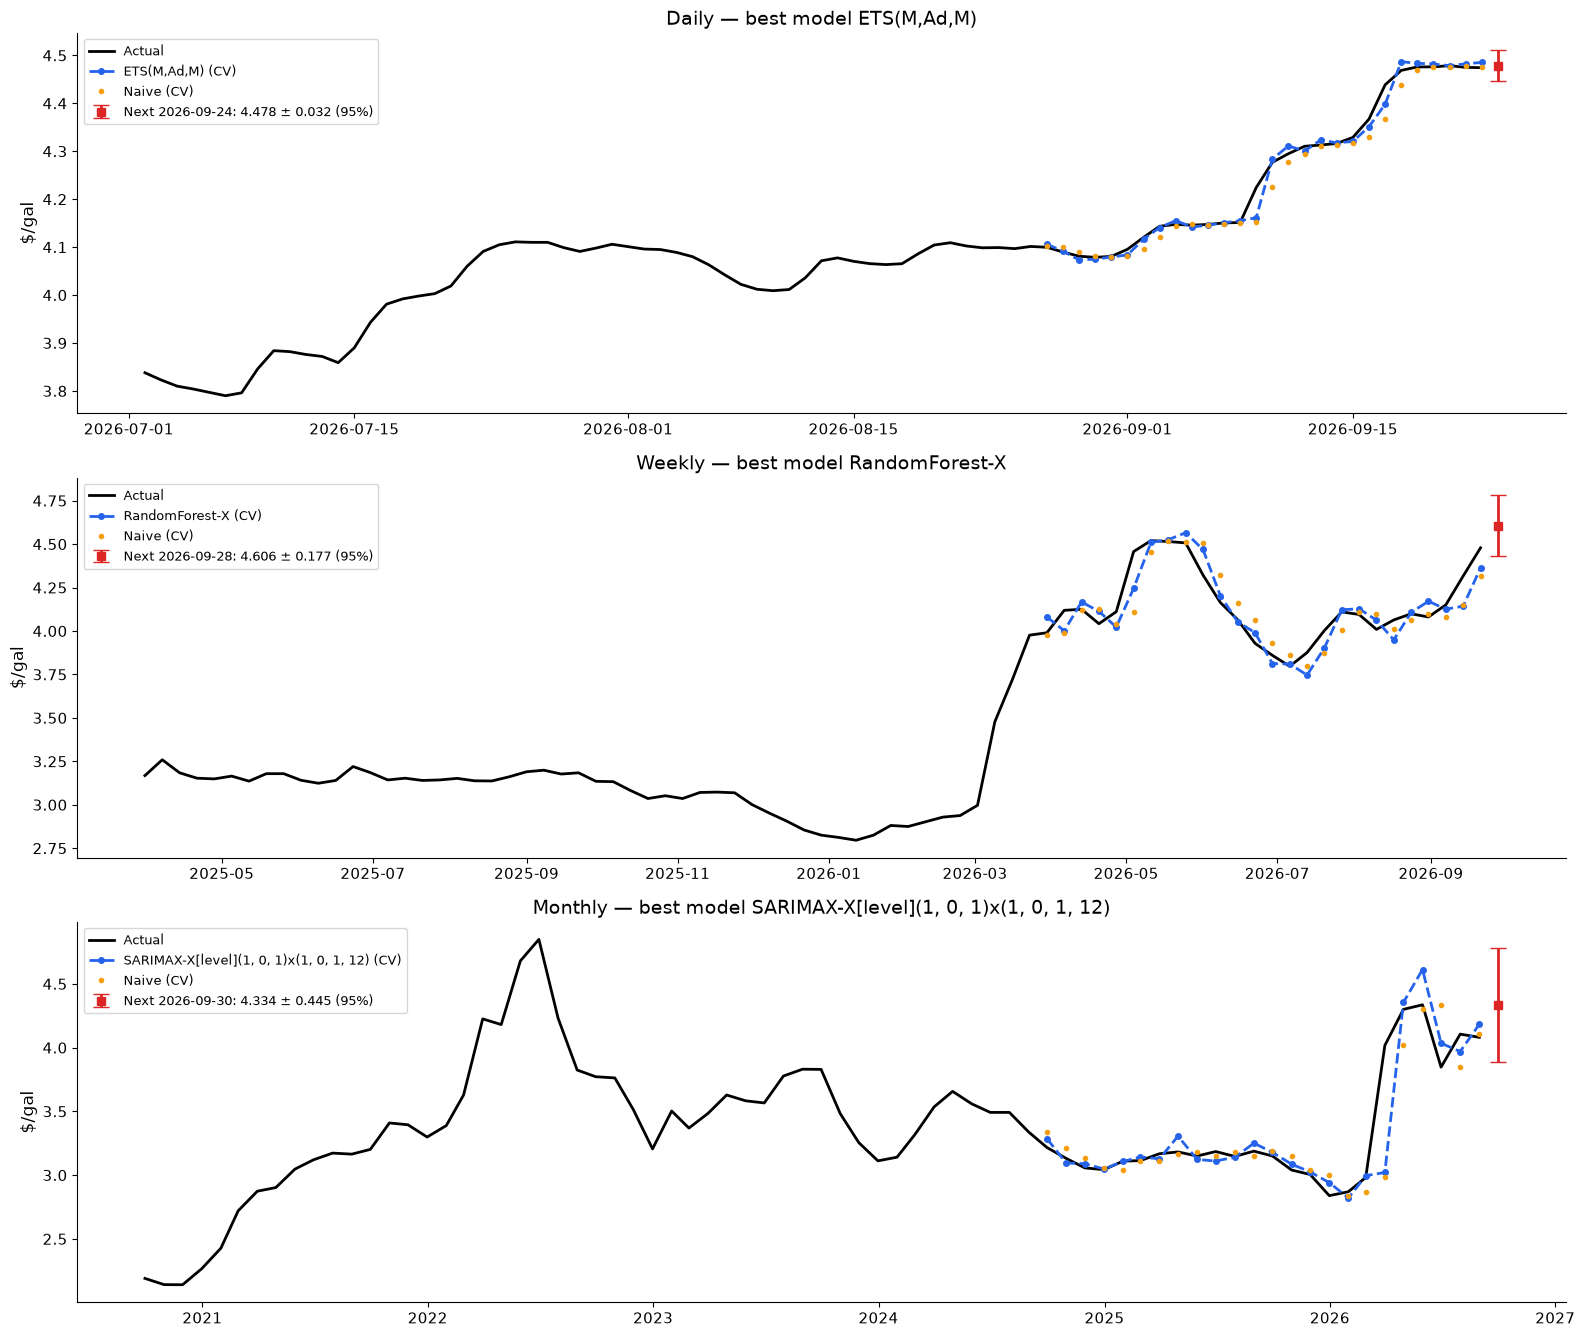

In [23]:
fig, axes = plt.subplots(len(T), 1, figsize=(16, 4.5 * len(T)), squeeze=False)
for ax, (k, t) in zip(axes[:, 0], T.items(), strict=False):
    b = t.best
    w = t.ts.iloc[-3 * spec.freqs[k].n_folds :]
    ax.plot(w.index, w.values, color="black", label="Actual")
    ax.plot(
        t.cv_pred[b].index,
        t.cv_pred[b].values,
        "o--",
        color="#2563eb",
        markersize=4,
        label=f"{b} (CV)",
    )
    ax.plot(
        t.cv_pred["Naive"].index,
        t.cv_pred["Naive"].values,
        ".",
        color="#f59e0b",
        label="Naive (CV)",
    )
    mu, sd = model_distribution(t.cv_err[b], t.forecasts[b])
    ax.errorbar(
        [t.next_date],
        [mu],
        yerr=[[1.96 * sd], [1.96 * sd]],
        fmt="s",
        color="#dc2626",
        capsize=6,
        label=f"Next {t.next_date:%Y-%m-%d}: {mu:.3f} ± {1.96 * sd:.3f} (95%)",
    )
    ax.set_title(f"{k.capitalize()} — best model {b}")
    ax.set_ylabel(spec.units)
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4.3 Export Forecast Data

In [24]:
for k, t in T.items():
    t.ranking.to_csv(OUT / f"{spec.number}_{spec.key}_{k}_ranking_{AS_OF:%Y%m%d}.csv")
summary.to_csv(OUT / f"{spec.number}_{spec.key}_summary_{AS_OF:%Y%m%d}.csv", index=False)
print(f"Saved to {OUT.resolve()}")

Saved to /Users/danielregalado/Desktop/Personal/GitHub/prediction-markets-forecasting/data/outputs


---
# Part 5: Critique & Next Steps

## Strengths of the Approach

| Strength | Detail |
|---|---|
| **Target = resolution source** | Kalshi's own `expiration_value`, validated against a long-history public record |
| **Honest driver selection** | Lead-lag on changes + Granger + placebo + with/without out-of-sample test |
| **No look-ahead** | Observed drivers lagged; only forecasts issued before the day enter at t |
| **Automatic stationarity** | `d`, `D` and the exog mode come from tests, identical in every notebook |
| **Same tournament for every market** | 14+ model types across 5 families; each frequency picks its own winner |
| **Random-walk benchmark** | Every model judged by skill vs Naive |

In [25]:
display(
    Markdown(
        "## Limitations (market-specific)\n\n| Limitation | Impact | Potential Mitigation |\n|---|---|---|\n"
        + "\n".join(f"| {a} | {b} | {c} |" for a, b, c in spec.limitations)
        + "\n| **No backtest vs historical Kalshi prices** | Part 6 edges are live signals, not proven P&L "
        "| Replay Kalshi candlesticks: model probability vs price at bet time |"
    )
)

## Limitations (market-specific)

| Limitation | Impact | Potential Mitigation |
|---|---|---|
| Daily history is short (~6 months) | Daily models and CV are noisy | Record AAA daily forward; paid AAA/OPIS history |
| Monthly model is stale | Forecasts month-end from last month-end | Use the daily nowcast in Part 6 |
| Market sees live station prices | Market σ is 2x tighter on daily/weekly | Bet weekly/monthly early in the period |
| Missing fundamentals | Inventories and refinery utilization not included | EIA API (free key) |
| No backtest vs historical Kalshi prices | Edges are live signals, not proven P&L | Replay Kalshi candlesticks |
| **No backtest vs historical Kalshi prices** | Part 6 edges are live signals, not proven P&L | Replay Kalshi candlesticks: model probability vs price at bet time |

---
# Part 6: Kalshi Translation — Forecast → Probability → Edge

1. **Model:** best model of the matching frequency, X ~ N(forecast + mean CV error, σ of CV errors) for events
   up to 3 periods ahead (recursive forecast; σ scaled by √h beyond one step — an approximation).
2. **Nowcast (when a finer series exists):** random walk from the latest fine observation with the empirical
   σ of h-step changes — the freshest information.
3. **Market:** mid-price of each bracket; its implied mean and σ are recovered from the whole ladder.
4. **Edge** = P − price − fee (≈ 0.07·P·(1−P)). A candidate needs edge > 3¢, and the nowcast must agree when it exists.

In [26]:
stamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M")
now_series = Y.get(spec.nowcast_freq) if spec.nowcast_freq else None
EDGES, SHARP = {}, []
for k in FREQS:
    t, cfg = T[k], spec.freqs[k]
    lad = kalshi.ladder(cfg.series)
    if lad.empty:
        print(f"{k}: no open markets")
        continue
    lad.to_csv(SNAP / f"{cfg.series}_{stamp}.csv", index=False)
    model = model_distribution(t.cv_err[t.best], t.forecasts[t.best])
    frames = []
    for ev, g in lad.groupby("event_date"):
        h = t.steps_to(ev)
        on_model = 1 <= h <= 3
        if on_model:
            path = t.forecast_path(t.best, h)
            dist = (path[-1] + np.mean(t.cv_err[t.best]), model[1] * np.sqrt(h))
        now = None
        if now_series is not None:
            h = (ev - now_series.index[-1]).days
            if h > 0:
                now = (float(now_series.iloc[-1]), float(max(now_series.diff(h).std(ddof=1), 1e-3)))
        et = edge_table(g, spec.integer, dist if on_model else None, now)
        et["bracket"] = [bracket_label(r) for _, r in et.iterrows()]
        et["on_model_date"] = on_model
        et["h"] = h
        if ev <= AS_OF:  # the event day has started: the market already sees observations
            et["signal"] = ""
        frames.append(et)
        mu_m, sd_m = implied_distribution(g, spec.integer)
        SHARP.append(
            {
                "frequency": k,
                "event": ev.date(),
                "event_started": ev <= AS_OF,
                "market_mu": mu_m,
                "market_sigma": sd_m,
                "h": h,
                "model_mu": dist[0] if on_model else np.nan,
                "model_sigma": dist[1] if on_model else np.nan,
                "nowcast_mu": now[0] if now else np.nan,
                "nowcast_sigma": now[1] if now else np.nan,
            }
        )
    EDGES[k] = pd.concat(frames)
    print(
        f'\n{"=" * 110}\n{k.upper()} {cfg.series} — best {t.best}: one-step μ={model[0]:.4f}, σ={model[1]:.4f} '
        f'for {t.next_date:%Y-%m-%d}\n{"=" * 110}'
    )
    cols = [
        "bracket",
        "yes_bid",
        "yes_ask",
        "no_ask",
        "mid",
        "p_model",
        "p_now",
        "edge_yes_model",
        "edge_no_model",
        "edge_yes_now",
        "edge_no_now",
        "signal",
        "volume",
    ]
    for ev, g in EDGES[k].groupby("event_date"):
        live = g[(g["mid"].between(0.02, 0.98)) | (g["p_model"].between(0.02, 0.98))]
        tag = (
            f'  [h={g["h"].iloc[0]}]'
            if g["on_model_date"].iloc[0]
            else "  [beyond 3 periods → nowcast only]"
        )
        tag += "  [EVENT DAY ALREADY STARTED — the market sees observations]" if ev <= AS_OF else ""
        print(f"\nEvent {ev:%Y-%m-%d}{tag}")
        print(live[cols].round(3).to_string(index=False))


DAILY KXAAAGASD — best ETS(M,Ad,M): one-step μ=4.4783, σ=0.0164 for 2026-09-24

Event 2026-09-24  [h=1]
bracket  yes_bid  yes_ask  no_ask   mid  p_model  p_now  edge_yes_model  edge_no_model  edge_yes_now  edge_no_now  signal   volume
> 4.445     0.99     1.00    0.01 0.995    0.979  0.908          -0.021          0.010        -0.092        0.082          2184.00
 > 4.45     0.99     1.00    0.01 0.995    0.958  0.865          -0.042          0.031        -0.135        0.125  BUY NO  3310.06
> 4.455     0.99     1.00    0.01 0.995    0.923  0.809          -0.077          0.066        -0.191        0.180  BUY NO  3388.46
 > 4.46     0.99     1.00    0.01 0.995    0.869  0.742          -0.131          0.121        -0.258        0.247  BUY NO  4144.68
> 4.465     0.98     1.00    0.02 0.990    0.792  0.664          -0.208          0.186        -0.336        0.314  BUY NO  8918.01
 > 4.47     0.98     0.99    0.02 0.985    0.695  0.579          -0.296          0.284        -0.412        0


WEEKLY KXAAAGASW — best RandomForest-X: one-step μ=4.6061, σ=0.0904 for 2026-09-28

Event 2026-09-28  [h=5]
bracket  yes_bid  yes_ask  no_ask   mid  p_model  p_now  edge_yes_model  edge_no_model  edge_yes_now  edge_no_now  signal   volume
 > 4.38     0.96     0.98    0.04 0.970    0.994  0.857           0.012         -0.036        -0.124        0.100          3203.92
  > 4.4     0.95     0.96    0.05 0.955    0.989  0.800           0.026         -0.042        -0.162        0.146          4848.22
 > 4.42     0.90     0.91    0.10 0.905    0.980  0.731           0.064         -0.086        -0.185        0.163          4572.58
 > 4.44     0.81     0.82    0.19 0.815    0.967  0.652           0.137         -0.168        -0.179        0.148          8721.78
 > 4.46     0.67     0.68    0.33 0.675    0.947  0.565           0.252         -0.292        -0.130        0.090          7820.37
 > 4.48     0.53     0.58    0.47 0.555    0.918  0.475           0.321         -0.406        -0.122     


MONTHLY KXAAAGASM — best SARIMAX-X[level](1, 0, 1)x(1, 0, 1, 12): one-step μ=4.3338, σ=0.2272 for 2026-09-30

Event 2026-09-30  [h=7]
bracket  yes_bid  yes_ask  no_ask   mid  p_model  p_now  edge_yes_model  edge_no_model  edge_yes_now  edge_no_now  signal   volume
  > 3.9     0.99     1.00    0.01 0.995    0.972  1.000          -0.028          0.017        -0.000       -0.011         14248.52
    > 4     0.99     1.00    0.01 0.995    0.929  1.000          -0.071          0.060        -0.000       -0.011         11512.54
  > 4.1     0.99     1.00    0.01 0.995    0.848  0.999          -0.152          0.141        -0.001       -0.010         65405.90
  > 4.2     0.98     1.00    0.02 0.990    0.722  0.991          -0.278          0.257        -0.009       -0.012         15732.27
  > 4.3     0.96     0.98    0.04 0.970    0.559  0.933          -0.422          0.398        -0.049        0.025         22591.68
  > 4.4     0.89     0.96    0.11 0.925    0.385  0.738          -0.577        

### Sanity check — how confident is the market compared with us?
If the market's σ is much smaller than ours, the market has information our models lack; a disagreement is then
far more likely *our* blind spot than an edge.

,frequency,event,event_started,market_mu,market_sigma,h,model_mu,model_sigma,nowcast_mu,nowcast_sigma,model_vs_market_sigma
0,daily,2026-09-24,False,4.481,0.007,1,4.478,0.016,4.474,0.022,2.291
1,weekly,2026-09-28,False,4.473,0.046,5,4.606,0.090,4.474,0.088,1.958
2,monthly,2026-09-30,False,4.486,0.172,7,4.334,0.227,4.474,0.117,1.319


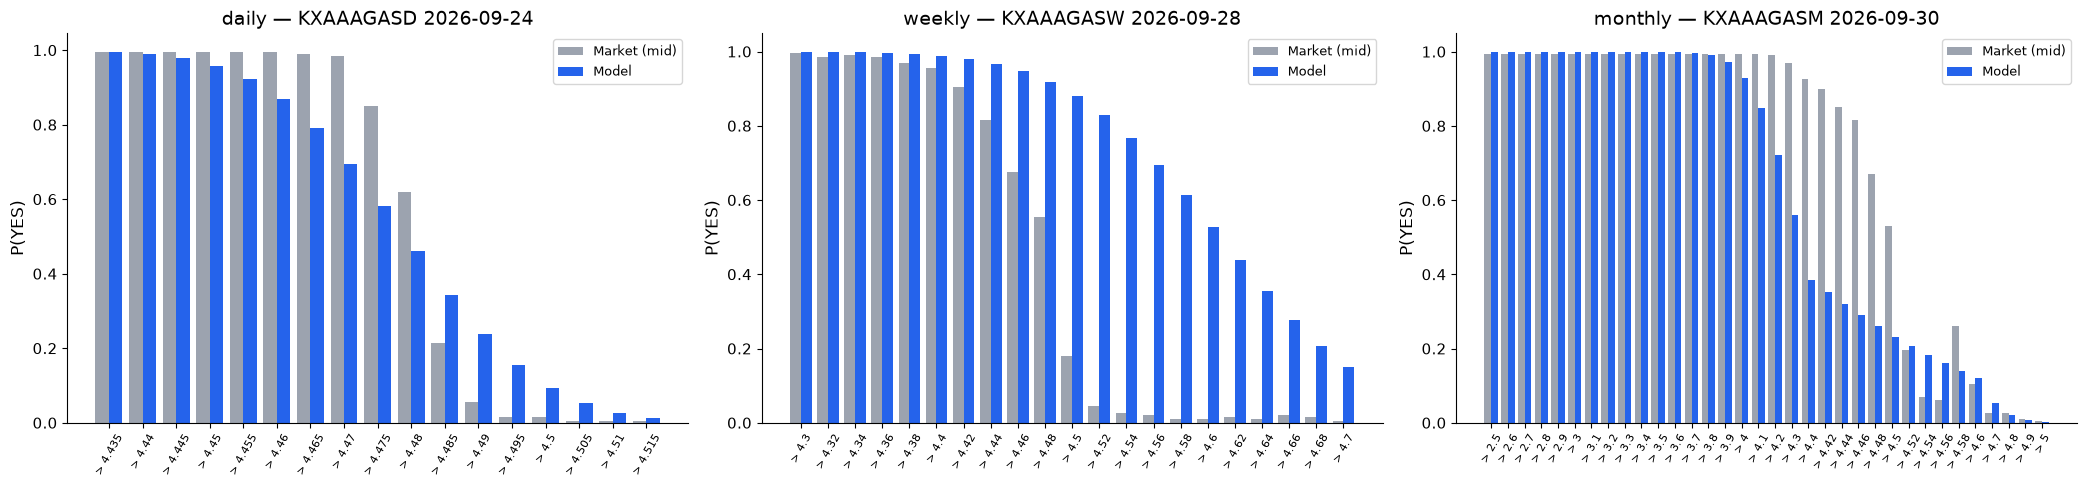

In [27]:
sharp = pd.DataFrame(SHARP)
sharp["model_vs_market_sigma"] = sharp["model_sigma"] / sharp["market_sigma"]
display(sharp.round(3))

evs = [(k, e) for k, e in EDGES.items() if e["on_model_date"].any()]
if evs:
    fig, axes = plt.subplots(1, len(evs), figsize=(7 * len(evs), 5), squeeze=False)
    for ax, (k, e) in zip(axes[0], evs, strict=False):
        g = e[e["on_model_date"] & (e["event_date"] > AS_OF)]
        g = (g if len(g) else e[e["on_model_date"]]).copy()
        g = g[g["event_date"] == g["event_date"].min()]
        x = np.arange(len(g))
        ax.bar(x - 0.2, g["mid"], 0.4, color="#9ca3af", label="Market (mid)")
        ax.bar(x + 0.2, g["p_model"], 0.4, color="#2563eb", label="Model")
        ax.set_xticks(x)
        ax.set_xticklabels(g["bracket"], rotation=60, fontsize=8)
        ax.set_title(f'{k} — {spec.freqs[k].series} {g["event_date"].iloc[0]:%Y-%m-%d}')
        ax.set_ylabel("P(YES)")
        ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

In [28]:
signals = pd.concat(EDGES.values()) if EDGES else pd.DataFrame()
signals = signals[signals.get("signal", pd.Series(dtype=str)) != ""] if len(signals) else signals
print("=" * 90)
print(f"CANDIDATE SIGNALS — {pd.Timestamp.now():%Y-%m-%d %H:%M}")
print("=" * 90)
wide = sharp[sharp["model_vs_market_sigma"] > 2]
if len(wide):
    print("WARNING — our σ is more than 2x the market-implied σ for:")
    print(
        wide[["frequency", "event", "market_mu", "market_sigma", "model_mu", "model_sigma"]]
        .round(3)
        .to_string(index=False)
    )
    print('Treat "edges" on these events as information gaps, not bets.\n')
started = sharp[sharp["event_started"]]
if len(started):
    print(
        f"NOTE — {len(started)} event(s) already started: the market sees today's observations.\n"
    )
if signals.empty:
    print("None.")
else:
    print(
        signals[
            [
                "ticker",
                "bracket",
                "yes_ask",
                "no_ask",
                "p_model",
                "p_now",
                "edge_yes_model",
                "edge_no_model",
                "signal",
                "volume",
            ]
        ]
        .round(3)
        .to_string(index=False)
    )
print(
    "\nNot validated against historical Kalshi prices yet — research signal, not a bet-sizing rule."
)

CANDIDATE SIGNALS — 2026-09-23 22:34
WARNING — our σ is more than 2x the market-implied σ for:
frequency      event  market_mu  market_sigma  model_mu  model_sigma
    daily 2026-09-24      4.481         0.007     4.478        0.016
Treat "edges" on these events as information gaps, not bets.

                  ticker bracket  yes_ask  no_ask  p_model  p_now  edge_yes_model  edge_no_model  signal   volume
KXAAAGASD-26SEP24-4.4500  > 4.45     1.00    0.01    0.958  0.865          -0.042          0.031  BUY NO  3310.06
KXAAAGASD-26SEP24-4.4550 > 4.455     1.00    0.01    0.923  0.809          -0.077          0.066  BUY NO  3388.46
KXAAAGASD-26SEP24-4.4600  > 4.46     1.00    0.01    0.869  0.742          -0.131          0.121  BUY NO  4144.68
KXAAAGASD-26SEP24-4.4650 > 4.465     1.00    0.02    0.792  0.664          -0.208          0.186  BUY NO  8918.01
KXAAAGASD-26SEP24-4.4700  > 4.47     0.99    0.02    0.695  0.579          -0.296          0.284  BUY NO  9777.29
KXAAAGASD-26SEP24-4.4